In [64]:
# Imports

from pathlib import Path
import pandas as pd
from openpyxl import load_workbook
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import os

import utils.building_data_loader as building_data_loader

In [65]:
BUILDING_CODE = "U06"

building_df = building_data_loader.get_building_dataframe(BUILDING_CODE)

In [66]:
# Info

building_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26275 entries, 0 to 26274
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   datetime                          26275 non-null  datetime64[ns]
 1   indoor_temp_constant_c            26275 non-null  int64         
 2   bhb01_measurement_cumulative_mwh  16154 non-null  float64       
 3   bhb01_supply_flow_temp_c          14326 non-null  float64       
 4   bhb01_return_flow_temp_c          14325 non-null  float64       
 5   bhb01_measurement_delta_mwh       15511 non-null  float64       
 6   bhb02_measurement_cumulative_mwh  21412 non-null  float64       
 7   bhb02_supply_flow_temp_c          20643 non-null  float64       
 8   bhb02_return_flow_temp_c          20643 non-null  float64       
 9   bhb02_measurement_delta_mwh       20700 non-null  float64       
 10  bhb03_measurement_cumulative_mwh  21412 non-nu

In [67]:
# We can see that the data has many empty values.

building_2023_df = building_df[building_df["datetime"].dt.year == 2023]
building_2023_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8760 entries, 8760 to 17519
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   datetime                          8760 non-null   datetime64[ns]
 1   indoor_temp_constant_c            8760 non-null   int64         
 2   bhb01_measurement_cumulative_mwh  8074 non-null   float64       
 3   bhb01_supply_flow_temp_c          8074 non-null   float64       
 4   bhb01_return_flow_temp_c          8074 non-null   float64       
 5   bhb01_measurement_delta_mwh       7513 non-null   float64       
 6   bhb02_measurement_cumulative_mwh  8074 non-null   float64       
 7   bhb02_supply_flow_temp_c          8074 non-null   float64       
 8   bhb02_return_flow_temp_c          8074 non-null   float64       
 9   bhb02_measurement_delta_mwh       7513 non-null   float64       
 10  bhb03_measurement_cumulative_mwh  8074 non-null  

In [68]:
columns = building_2023_df.columns

print(columns)

Index(['datetime', 'indoor_temp_constant_c',
       'bhb01_measurement_cumulative_mwh', 'bhb01_supply_flow_temp_c',
       'bhb01_return_flow_temp_c', 'bhb01_measurement_delta_mwh',
       'bhb02_measurement_cumulative_mwh', 'bhb02_supply_flow_temp_c',
       'bhb02_return_flow_temp_c', 'bhb02_measurement_delta_mwh',
       'bhb03_measurement_cumulative_mwh', 'bhb03_supply_flow_temp_c',
       'bhb03_return_flow_temp_c', 'bhb03_measurement_delta_mwh',
       'bhb04_measurement_cumulative_mwh', 'bhb04_supply_flow_temp_c',
       'bhb04_return_flow_temp_c', 'bhb04_measurement_delta_mwh',
       'bhb05_measurement_cumulative_mwh', 'bhb05_supply_flow_temp_c',
       'bhb05_return_flow_temp_c', 'bhb05_measurement_delta_mwh',
       'bhb06_measurement_cumulative_mwh', 'bhb06_supply_flow_temp_c',
       'bhb06_return_flow_temp_c', 'bhb06_measurement_delta_mwh',
       'air_pressure_hpa', 'precipitation_mm', 'relative_humidity_pct',
       'sunshine_duration_min', 'air_temp_c', 'air_temp_min_c

---
## ES baselines from Smertians et al.

**Reference:** Smertians et al., *Estimation of Building Energy Demand Characteristics using Bayesian Statistics and Energy Signature Models*.

### What an ES model needs (minimum)

| Input | Role |
|-------|------|
| **Φ(t)** | Heat demand at time step *t* (energy or power) |
| **T_out(t)** | Outdoor air temperature |

### Modern ES (paper uses)

| Input | Role |
|-------|------|
| **Wind speed** | Infiltration losses |
| **Solar proxy** | Solar gains |

Optional: indoor temperature (or constant setpoint); supply/return temps for diagnostics only.

### Model equation (ES v1 — deterministic baseline)

$$
\Phi(t) = \underbrace{UA \cdot (T_{base} - T_{out}(t))}_{\text{heat loss}} + \underbrace{\beta_{wind} \cdot W(t)}_{\text{wind}} - \underbrace{\beta_{sun} \cdot S(t)}_{\text{solar}} + \underbrace{\Phi_{base}}_{\text{offset}}
$$

With constraint: **Φ(t) ≥ Φ_base**.

### Parameters to estimate

| Parameter | Meaning |
|-----------|--------|
| *UA* | Heat loss coefficient |
| *T_base* | Balance temperature |
| *β_wind* | Infiltration sensitivity |
| *β_sun* | Solar gain |
| *Φ_base* | Base load |

### Aggregation (paper: daily for robustness)

- **Heat** → sum  
- **T_out** → mean  
- **Wind** → mean  
- **Sunshine** → sum  

Filter: drop days with zero/negative heat when cold, missing weather, or meter resets.

---
## Data → ES mapping

| ES variable | Our column | Unit / note |
|-------------|------------|-------------|
| Φ(t) | `bhbXX_measurement_delta_mwh` | MWh per interval → kWh (×1000) |
| T_out(t) | `air_temp_c` | °C |
| W(t) | `wind_speed_ms` | m/s |
| S(t) | `sunshine_duration_min` | min (solar proxy) |

For v1 we **pick one meter** (e.g. `bhb01`). Indoor temp and supply/return are skipped for this baseline.

In [69]:
# --- ES v1: pick one meter and build ES inputs (hourly) ---
HEAT_METER = "bhb01"  # or sum of bhb01--bhb06 for same zone
heat_col = f"{HEAT_METER}_measurement_delta_mwh"

# ES inputs: Φ [kWh], T_out [°C], W [m/s], S [min]
es_hourly = building_2023_df[["datetime", heat_col, "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
es_hourly = es_hourly.rename(columns={
    heat_col: "heat_mwh",
    "air_temp_c": "T_out_c",
    "wind_speed_ms": "wind_ms",
    "sunshine_duration_min": "sun_min",
})
es_hourly["Phi_kWh"] = es_hourly["heat_mwh"] * 1e3
es_hourly = es_hourly.drop(columns=["heat_mwh"])

# Drop rows where any ES input is missing
es_hourly = es_hourly.dropna()
print("Hourly ES-ready rows:", len(es_hourly))
es_hourly.head()

Hourly ES-ready rows: 7483


,datetime,T_out_c,wind_ms,sun_min,Phi_kWh
8760,2023-01-01 00:00:00,5.2,4.3,0.0,110.0
8761,2023-01-01 01:00:00,4.8,4.2,0.0,110.0
8762,2023-01-01 02:00:00,4.1,3.9,0.0,120.0
8763,2023-01-01 03:00:00,3.3,2.6,0.0,120.0
8764,2023-01-01 04:00:00,2.8,2.0,0.0,120.0


In [70]:
# --- Aggregate to daily (paper: sum heat, mean temp/wind, sum sun) ---
es_hourly["date"] = es_hourly["datetime"].dt.date

daily = (
    es_hourly.groupby("date", as_index=False)
    .agg(
        daily_heat_kWh=("Phi_kWh", "sum"),
        daily_T_out_c=("T_out_c", "mean"),
        daily_wind_ms=("wind_ms", "mean"),
        daily_sun_min=("sun_min", "sum"),
    )
)
# Filter garbage: no zero/negative heat when it's cold; drop missing
daily = daily.dropna()
daily = daily[daily["daily_heat_kWh"] > 0]
# Optional: drop days with T_out < 0 and suspiciously zero heat (already dropped by > 0)
print("Daily ES-ready rows:", len(daily))
daily.head(10)

Daily ES-ready rows: 360


,date,daily_heat_kWh,daily_T_out_c,daily_wind_ms,daily_sun_min
0,2023-01-01,3500.0,0.877273,1.804545,0.0
1,2023-01-02,4780.0,-1.115000,3.030000,0.0
2,2023-01-03,2520.0,0.376923,4.169231,0.0
3,2023-01-04,3070.0,-2.800000,3.430769,0.0
4,2023-01-05,5505.0,-6.060000,4.630000,68.0
5,2023-01-06,5625.0,-7.055000,2.000000,0.0
6,2023-01-07,6140.0,-13.000000,4.060000,30.0
7,2023-01-08,5340.0,-9.794737,5.342105,0.0
8,2023-01-09,4220.0,-5.511765,4.617647,0.0
9,2023-01-10,3830.0,-2.112500,3.650000,0.0


---
## ES v1: deterministic linear model

We fit:

**Φ_daily = (−UA)·T_out + β_wind·W + (−β_sun)·S + (UA·T_base + Φ_base)**

as a linear regression: `daily_heat_kWh = a·T_out + b·W + c·S + d`. Then:
- *UA* = −*a*, *β_wind* = *b*, *β_sun* = −*c*, and intercept *d* = UA·T_base + Φ_base (for v1 we do not split *d* into T_base and Φ_base; we just report coefficients and intercept).

### Interpreting R²

**R² = 1 − (SS_res / SS_tot)** is the fraction of variance in daily heat explained by the model (T_out, wind, sun).

- **R² ≈ 0.87** → ~87% of day-to-day variation in demand is explained by weather; the rest is other factors (occupancy, setpoints, measurement noise).
- **Rule of thumb:** R² > 0.8 is strong for building daily demand; 0.5–0.8 is common; &lt; 0.5 suggests weak weather–demand link or noisy/mixed meters.
- R² is in-sample; compare with RMSE and (later) residual ACF to judge fit quality.

In [ ]:
# --- Fit ES v1 (OLS) ---
from sklearn.linear_model import LinearRegression

X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]]
y = daily["daily_heat_kWh"]
X.columns = ["T_out_c", "wind_ms", "sun_min"]

lm = LinearRegression().fit(X, y)
daily["predicted_heat_kWh"] = lm.predict(X)
daily["residual_kWh"] = daily["daily_heat_kWh"] - daily["predicted_heat_kWh"]

# Coefficients → physical params: Φ = (-UA)*T_out + β_wind*W + (-β_sun)*S + d
coef = lm.coef_
intercept = lm.intercept_
UA_est = -coef[0]
beta_wind_est = coef[1]
beta_sun_est = -coef[2]
print("ES v1 coefficients (daily):")
print(f"  UA (heat loss)     ≈ {UA_est:.2f} kWh/(°C·day)")
print(f"  β_wind             ≈ {beta_wind_est:.2f} kWh/(m/s·day)")
print(f"  β_sun              ≈ {beta_sun_est:.2f} kWh/(min·day)")
print(f"  intercept (d)      ≈ {intercept:.2f} kWh/day")
print(f"  R²                 = {lm.score(X, y):.4f}")
rmse = np.sqrt(np.mean(daily["residual_kWh"] ** 2))
print(f"  RMSE               = {rmse:.2f} kWh/day")

ES v1 coefficients (daily):
  UA (heat loss)     ≈ 191.61 kWh/(°C·day)
  β_wind             ≈ 23.38 kWh/(m/s·day)
  β_sun              ≈ 0.34 kWh/(min·day)
  intercept (d)      ≈ 3370.44 kWh/day
  R²                 = 0.8715
  RMSE               = 630.58 kWh/day


---
## Diagnostics (v1)

- **Heat vs outdoor temp**: scatter + trend (colder → more heat).
- **Residuals vs time**: spot spikes and seasonality.
- **Residuals vs wind**: check if wind is under/over-captured.

/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


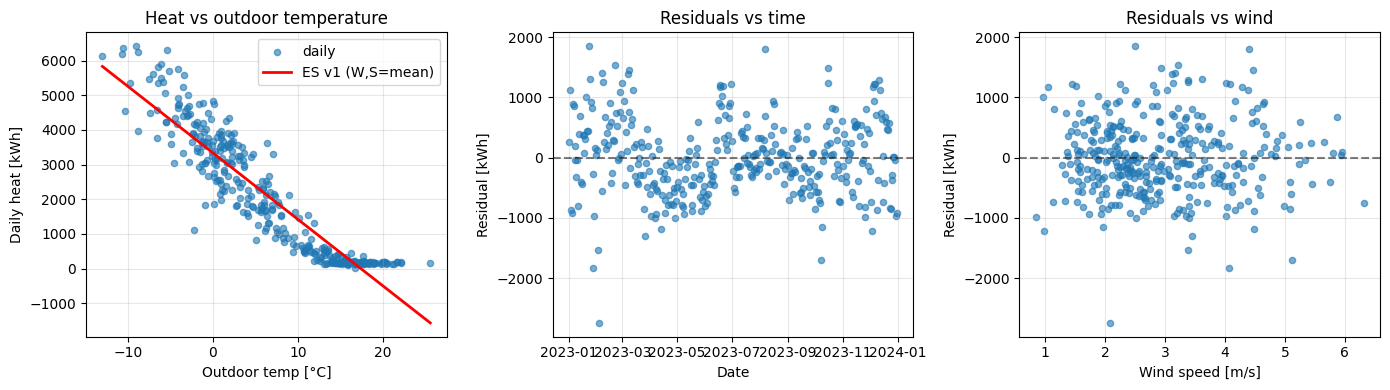

In [ ]:
# --- Plots: heat vs T_out, residuals vs time, residuals vs wind ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Heat vs outdoor temp
ax = axes[0]
ax.scatter(daily["daily_T_out_c"], daily["daily_heat_kWh"], alpha=0.6, s=20, label="daily")
# Optional: add predicted curve vs T_out (fix W, S at mean)
W_mean, S_mean = daily["daily_wind_ms"].mean(), daily["daily_sun_min"].mean()
T_grid = np.linspace(daily["daily_T_out_c"].min(), daily["daily_T_out_c"].max(), 100)
pred_curve = lm.predict(np.column_stack([T_grid, np.full(100, W_mean), np.full(100, S_mean)]))
ax.plot(T_grid, pred_curve, "r-", lw=2, label="ES v1 (W,S=mean)")
ax.set_xlabel("Outdoor temp [°C]")
ax.set_ylabel("Daily heat [kWh]")
ax.set_title("Heat vs outdoor temperature")
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Residuals vs time
ax = axes[1]
daily["date"] = pd.to_datetime(daily["date"])
ax.scatter(daily["date"], daily["residual_kWh"], alpha=0.6, s=20)
ax.axhline(0, color="k", ls="--", alpha=0.5)
ax.set_xlabel("Date")
ax.set_ylabel("Residual [kWh]")
ax.set_title("Residuals vs time")
ax.grid(True, alpha=0.3)

# 3) Residuals vs wind
ax = axes[2]
ax.scatter(daily["daily_wind_ms"], daily["residual_kWh"], alpha=0.6, s=20)
ax.axhline(0, color="k", ls="--", alpha=0.5)
ax.set_xlabel("Wind speed [m/s]")
ax.set_ylabel("Residual [kWh]")
ax.set_title("Residuals vs wind")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def run_es_v1(df, heat_columns, label=None):
    """
    ES v1: aggregate to daily, fit Φ = (-UA)*T_out + β_wind*W + (-β_sun)*S + d.
    heat_columns: str (one col) or list of str (sum them). Cols are measurement_delta_mwh.
    label: name for this run (e.g. "bhb01", "all").
    Returns: dict with sensor, UA, beta_wind, beta_sun, intercept, R2, RMSE, n_days.
    """
    from sklearn.linear_model import LinearRegression

    cols = [heat_columns] if isinstance(heat_columns, str) else heat_columns
    phi_mwh = df[cols].sum(axis=1) if len(cols) > 1 else df[cols[0]]
    es = df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
    es["Phi_kWh"] = phi_mwh * 1e3
    es = es.dropna()
    es["date"] = es["datetime"].dt.date

    daily = (
        es.groupby("date", as_index=False)
        .agg(
            daily_heat_kWh=("Phi_kWh", "sum"),
            daily_T_out_c=("air_temp_c", "mean"),
            daily_wind_ms=("wind_speed_ms", "mean"),
            daily_sun_min=("sunshine_duration_min", "sum"),
        )
    )
    daily = daily.dropna()
    daily = daily[daily["daily_heat_kWh"] > 0]
    if len(daily) < 10:
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}

    X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]]
    y = daily["daily_heat_kWh"]
    lm = LinearRegression().fit(X, y)
    res = y - lm.predict(X)
    coef, intercept = lm.coef_, lm.intercept_

    return {
        "sensor": label or str(cols),
        "UA": -coef[0],
        "beta_wind": coef[1],
        "beta_sun": -coef[2],
        "intercept": intercept,
        "R2": lm.score(X, y),
        "RMSE": np.sqrt(np.mean(res ** 2)),
        "n_days": len(daily),
    }

---
## ES with AR(1) (thermal inertia)

Add **lagged daily heat** so today’s demand depends on yesterday’s (building thermal mass):

**Φ(t) = (−UA)·T_out(t) + β_wind·W(t) + (−β_sun)·S(t) + ρ·Φ(t−1) + d**

We fit with one extra regressor: `daily_heat_kWh_lag1`. First day has no lag, so we drop it for the regression.

### Interpreting R² and ρ (AR(1))

- **R² (R-squared):** Fraction of variance in daily heat explained by the model. Same meaning for both v1 and AR(1); AR(1) usually has **higher R²** because it adds lagged heat as a predictor.
- **R2_v1 vs R2_AR1:** Baseline (weather only) vs AR(1) (weather + yesterday’s heat). If R2_AR1 &gt; R2_v1 and RMSE_AR1 &lt; RMSE_v1, the AR term is helping (thermal inertia is relevant).
- **ρ (rho):** AR(1) coefficient — how much of yesterday’s heat “carries over” into today (building thermal mass). Typically **0 &lt; ρ &lt; 1**; higher ρ = stronger inertia (smoother, more persistent demand). ρ ≈ 0 means lag doesn’t help; ρ close to 1 means demand is very persistent day-to-day.

In [ ]:
def run_es_ar1(df, heat_columns, label=None):
    """
    ES + AR(1): same as run_es_v1 but add lagged daily heat Φ(t-1).
    Returns: dict like run_es_v1 plus rho (AR coefficient).
    """
    from sklearn.linear_model import LinearRegression

    cols = [heat_columns] if isinstance(heat_columns, str) else heat_columns
    phi_mwh = df[cols].sum(axis=1) if len(cols) > 1 else df[cols[0]]
    es = df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
    es["Phi_kWh"] = phi_mwh * 1e3
    es = es.dropna()
    es["date"] = es["datetime"].dt.date

    daily = (
        es.groupby("date", as_index=False)
        .agg(
            daily_heat_kWh=("Phi_kWh", "sum"),
            daily_T_out_c=("air_temp_c", "mean"),
            daily_wind_ms=("wind_speed_ms", "mean"),
            daily_sun_min=("sunshine_duration_min", "sum"),
        )
    )
    daily = daily.dropna()
    daily = daily[daily["daily_heat_kWh"] > 0]
    daily = daily.sort_values("date").reset_index(drop=True)
    daily["daily_heat_kWh_lag1"] = daily["daily_heat_kWh"].shift(1)
    daily = daily.dropna()  # drop first row (no lag)
    if len(daily) < 10:
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}

    X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min", "daily_heat_kWh_lag1"]]
    y = daily["daily_heat_kWh"]
    lm = LinearRegression().fit(X, y)
    res = y - lm.predict(X)
    coef, intercept = lm.coef_, lm.intercept_

    return {
        "sensor": label or str(cols),
        "UA": -coef[0],
        "beta_wind": coef[1],
        "beta_sun": -coef[2],
        "rho": coef[3],
        "intercept": intercept,
        "R2": lm.score(X, y),
        "RMSE": np.sqrt(np.mean(res ** 2)),
        "n_days": len(daily),
    }

In [ ]:
!pip install statsmodels


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [76]:
def run_es_armax(df, heat_columns, label=None, order=(1, 0, 3)):
    """ES + ARMAX: ARIMA(1,0,3) with exogenous regressors (T_out, wind, sun). Returns R2 (Gaussian R²), RMSE, UA, beta_wind, etc."""
    import warnings
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tools.sm_exceptions import ConvergenceWarning
    cols = [heat_columns] if isinstance(heat_columns, str) else list(heat_columns)
    phi_mwh = df[cols].sum(axis=1) if len(cols) > 1 else df[cols[0]]
    es = df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
    es["Phi_kWh"] = phi_mwh * 1e3
    es = es.dropna()
    es["date"] = es["datetime"].dt.date
    daily = es.groupby("date", as_index=False).agg(daily_heat_kWh=("Phi_kWh", "sum"), daily_T_out_c=("air_temp_c", "mean"), daily_wind_ms=("wind_speed_ms", "mean"), daily_sun_min=("sunshine_duration_min", "sum"))
    daily = daily.dropna()
    daily = daily[daily["daily_heat_kWh"] > 0].sort_values("date").reset_index(drop=True)
    if len(daily) < 40:
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}
    y = daily["daily_heat_kWh"].values
    X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]].values
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            mod = ARIMA(y, exog=X, order=order)
            res = mod.fit()
    except Exception:
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}
    fitted = res.fittedvalues
    resid = y - fitted
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean(resid ** 2))
    params = np.asarray(res.params)
    n_exog = res.model.k_exog
    intercept = float(params[0]) if n_exog >= 4 else 0.0
    ua = -float(params[1]) if len(params) > 1 else np.nan
    beta_wind = float(params[2]) if len(params) > 2 else np.nan
    beta_sun = -float(params[3]) if len(params) > 3 else np.nan
    rho = float(res.arparams[0]) if hasattr(res, "arparams") and len(res.arparams) > 0 else np.nan
    ma_coefs = list(res.maparams) if hasattr(res, "maparams") else []
    return {"sensor": label or str(cols), "UA": ua, "beta_wind": beta_wind, "beta_sun": beta_sun, "intercept": intercept, "rho": rho, "ma_coefs": ma_coefs, "R2": r2, "RMSE": rmse, "n_days": len(daily)}

# Run ES AR(1) and ARMAX per sensor and combined
HEAT_METERS = [f"bhb{i:02d}" for i in range(1, 7)]
delta_cols = [f"{m}_measurement_delta_mwh" for m in HEAT_METERS]
rows_ar1 = []
for m in HEAT_METERS:
    rows_ar1.append(run_es_ar1(building_2023_df, f"{m}_measurement_delta_mwh", label=m))
rows_ar1.append(run_es_ar1(building_2023_df, delta_cols, label="all"))
es_ar1_summary = pd.DataFrame(rows_ar1)

rows_armax = []
for m in HEAT_METERS:
    rows_armax.append(run_es_armax(building_2023_df, f"{m}_measurement_delta_mwh", label=m))
rows_armax.append(run_es_armax(building_2023_df, delta_cols, label="all"))
es_armax_summary = pd.DataFrame(rows_armax)

# Compare R2 and RMSE: v1 vs AR(1) vs ARMAX (build es_v1_summary if not yet run)
if "es_v1_summary" not in dir():
    rows_v1 = []
    for m in HEAT_METERS:
        rows_v1.append(run_es_v1(building_2023_df, f"{m}_measurement_delta_mwh", label=m))
    rows_v1.append(run_es_v1(building_2023_df, delta_cols, label="all"))
    es_v1_summary = pd.DataFrame(rows_v1)
compare = es_v1_summary[["sensor", "R2", "RMSE"]].copy()
compare = compare.rename(columns={"R2": "R2_v1", "RMSE": "RMSE_v1"})
compare["R2_AR1"] = es_ar1_summary["R2"].values
compare["RMSE_AR1"] = es_ar1_summary["RMSE"].values
compare["R2_ARMAX"] = es_armax_summary["R2"].values
compare["RMSE_ARMAX"] = es_armax_summary["RMSE"].values
compare["rho"] = es_ar1_summary["rho"].values
compare

/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,sensor,R2_v1,RMSE_v1,R2_AR1,RMSE_AR1,R2_ARMAX,RMSE_ARMAX,rho
0,bhb01,0.871536,630.576478,0.917214,506.400102,0.922039,491.229626,0.526956
1,bhb02,0.208549,6.430820,0.240145,6.358576,0.385779,5.665222,0.203448
2,bhb03,0.593780,261.826770,0.792469,186.415220,0.805634,181.110559,0.655048
3,bhb04,0.861914,291.793990,0.912803,232.142518,0.920466,221.450237,0.535943
4,bhb05,0.127405,22.378006,0.242351,20.851875,0.297373,20.080630,0.365347
5,bhb06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,all,0.876374,1047.536400,0.919091,847.569310,0.924544,818.395011,0.520784


---
## Paper-style histograms (Smertinas et al. comparison)

Smertinas et al. use several key figures we can mirror with our data:

| Paper figure | Description | Our analogue |
|--------------|-------------|--------------|
| **Fig 3** | Daily energy use over time (box: MIN, Q1, MEDIAN, Q3, MAX, MEAN) | Single building: daily heat by date/month |
| **Fig 4** | EPC label distribution | *(No EPC in campus data; could use building type if available)* |
| **Fig 5** | Bayesian R² histograms (ES vs ARX-ES vs ARMAX-ES) | R² histograms: ES v1 vs AR(1) across sensors |
| **Fig 6** | ELPD LOO histograms | *(Requires Bayesian fits, e.g. PyMC; skip for now)* |
| **Fig 7** | ACF of residuals (box plot by lag, ES vs ARX vs ARMAX) | ACF of residuals: ES v1 vs AR(1) |
| **Fig 8** | Parameter histograms (UA₀, UAw, Tb, gA, Φbase, k) | Parameter histograms: UA, β_wind, intercept (ES v1 vs AR1) |

### Data format alignment with the paper

| Paper (Smertinas et al.) | Our data | Match? | Suggestion |
|-------------------------|----------|--------|------------|
| **Φ** daily heat | `daily_heat_kWh` (sum per day) | ✓ Same idea | Paper uses **daily average power** (MW) then normalises by area → W/m². We use kWh/day; add **heated area A** to report W/m². |
| **T_out** | `air_temp_c` → `daily_T_out_c` (mean) | ✓ | — |
| **Wind** | `wind_speed_ms` → `daily_wind_ms` (mean) | ✓ | — |
| **Solar** | Global irradiance **I_g [W/m²]** | Proxy | We use **sunshine_duration_min** (proxy). For closer match, derive or obtain **global solar radiation [W/m²]** (e.g. from clear-sky or weather API). |
| **Heated area A** | — | ✗ | Add **A [m²]** per building (from BBR/EPC or manual) to normalise heat to **W/m²** and compare with paper. |
| **Temporal** | Daily | Daily | ✓ |
| **Building set** | n=2788, EPC-labeled | Single building, multiple meters | Run over **multiple buildings** (U01, U02, …) to get population histograms like the paper. |

### Features to build for closer comparison

1. **Heated area A [m²]** – From overview or separate metadata; then: `daily_heat_W_per_m2 = (daily_heat_kWh * 1000 / 24) / A`.
2. **Global solar irradiance [W/m²]** – Replace or complement `sunshine_duration_min` with irradiance (e.g. ERA5/CDS or clear-sky model).
3. **Multi-building pipeline** – Loop over all buildings with heat meters, aggregate daily, fit ES v1 and AR(1), collect R² and parameters to reproduce Fig 5 and Fig 8 style **population** histograms.
4. **EPC or energy label** – If available (e.g. from BBR or campus records), add for Fig 4 style distribution.

/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_10647/1403616482.py:20: FutureWarning: The provided callable <function min at 0x107ce2440> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  stats = daily_all.groupby("month")["daily_heat_kWh"].agg(
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_10647/1403616482.py:20: FutureWarning: The provided callable <function median at 0x107e46e60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  stats = daily_all.groupby("month")["daily_heat_kWh"].agg(
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_10647/1403616482.py:20: FutureWarning: The provided callable <function max at 0x107ce2320> is currently using SeriesGroupBy.max. In a future version of pandas, the provided

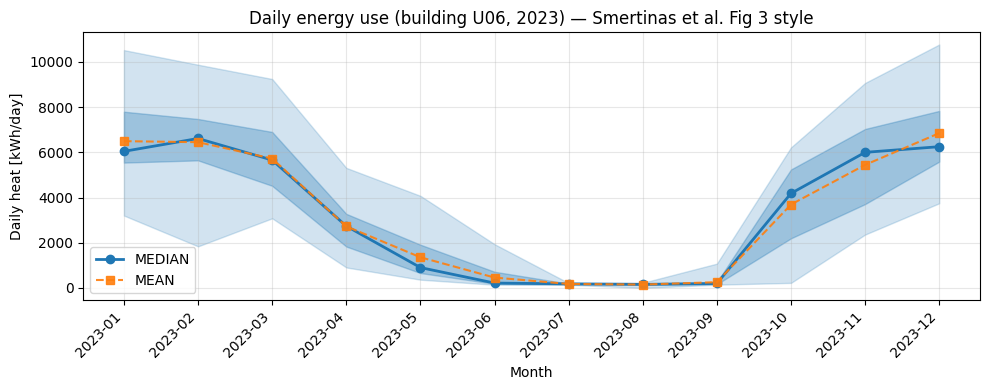

In [77]:
# --- Fig 3 style: Daily energy use over time (Smertinas et al. Fig 3) ---
# Paper: box plot of daily energy (space heating + DHW) by time; we use single building, daily heat by month.

delta_cols = [f"bhb{i:02d}_measurement_delta_mwh" for i in range(1, 7)]
es_all = building_2023_df[["datetime"] + delta_cols + ["air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
es_all["Phi_kWh"] = es_all[delta_cols].sum(axis=1) * 1e3
es_all = es_all.rename(columns={"air_temp_c": "T_out_c", "wind_speed_ms": "wind_ms", "sunshine_duration_min": "sun_min"})
es_all = es_all[["datetime", "T_out_c", "wind_ms", "sun_min", "Phi_kWh"]].dropna()
es_all["date"] = es_all["datetime"].dt.date
daily_all = (
    es_all.groupby("date", as_index=False)
    .agg(daily_heat_kWh=("Phi_kWh", "sum"), daily_T_out_c=("T_out_c", "mean"), daily_wind_ms=("wind_ms", "mean"), daily_sun_min=("sun_min", "sum"))
)
daily_all = daily_all.dropna()
daily_all = daily_all[daily_all["daily_heat_kWh"] > 0].copy()
daily_all["date"] = pd.to_datetime(daily_all["date"])
daily_all["month"] = daily_all["date"].dt.to_period("M").astype(str)

fig, ax = plt.subplots(figsize=(10, 4))
stats = daily_all.groupby("month")["daily_heat_kWh"].agg(
    MIN=np.min, Q1=lambda s: s.quantile(0.25), MEDIAN=np.median,
    Q3=lambda s: s.quantile(0.75), MAX=np.max, MEAN=np.mean
)
x = np.arange(len(stats))
ax.fill_between(x, stats["MIN"], stats["MAX"], alpha=0.2, color="C0")
ax.fill_between(x, stats["Q1"], stats["Q3"], alpha=0.3, color="C0")
ax.plot(x, stats["MEDIAN"], "o-", color="C0", label="MEDIAN", lw=2)
ax.plot(x, stats["MEAN"], "s--", color="C1", label="MEAN", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(stats.index, rotation=45, ha="right")
ax.set_xlabel("Month")
ax.set_ylabel("Daily heat [kWh/day]")
ax.set_title("Daily energy use (building U06, 2023) — Smertinas et al. Fig 3 style")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

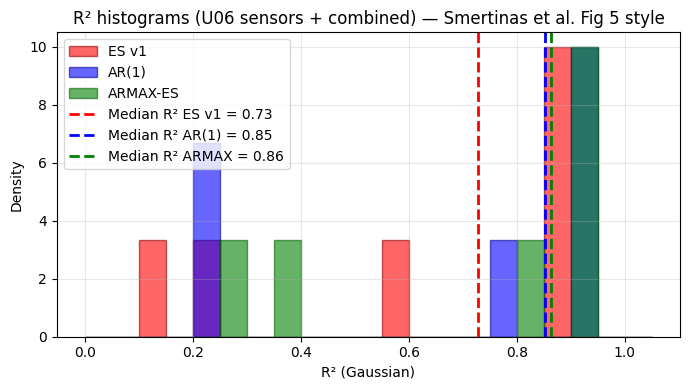

In [78]:
# --- Fig 5 style: R² histograms (Smertinas et al. Fig 5: ES vs ARX vs ARMAX) ---
# Our analogue: ES v1 vs AR(1) vs ARMAX across sensors; paper uses Bayesian R², we use Gaussian R².

df_r2 = compare.dropna(subset=["R2_v1", "R2_AR1"]).copy()
if "R2_ARMAX" in compare.columns:
    df_r2 = df_r2.dropna(subset=["R2_ARMAX"])
bins = np.linspace(0, 1.05, 22)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_r2["R2_v1"], bins=bins, alpha=0.6, color="red", label="ES v1", density=True, edgecolor="darkred")
ax.hist(df_r2["R2_AR1"], bins=bins, alpha=0.6, color="blue", label="AR(1)", density=True, edgecolor="darkblue")
if "R2_ARMAX" in compare.columns and compare["R2_ARMAX"].notna().any():
    ax.hist(df_r2["R2_ARMAX"], bins=bins, alpha=0.6, color="green", label="ARMAX-ES", density=True, edgecolor="darkgreen")
ax.axvline(df_r2["R2_v1"].median(), color="red", ls="--", lw=2, label=f"Median R² ES v1 = {df_r2['R2_v1'].median():.2f}")
ax.axvline(df_r2["R2_AR1"].median(), color="blue", ls="--", lw=2, label=f"Median R² AR(1) = {df_r2['R2_AR1'].median():.2f}")
if "R2_ARMAX" in compare.columns and compare["R2_ARMAX"].notna().any():
    ax.axvline(df_r2["R2_ARMAX"].median(), color="green", ls="--", lw=2, label=f"Median R² ARMAX = {df_r2['R2_ARMAX'].median():.2f}")
ax.set_xlabel("R² (Gaussian)")
ax.set_ylabel("Density")
ax.set_title("R² histograms (U06 sensors + combined) — Smertinas et al. Fig 5 style")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

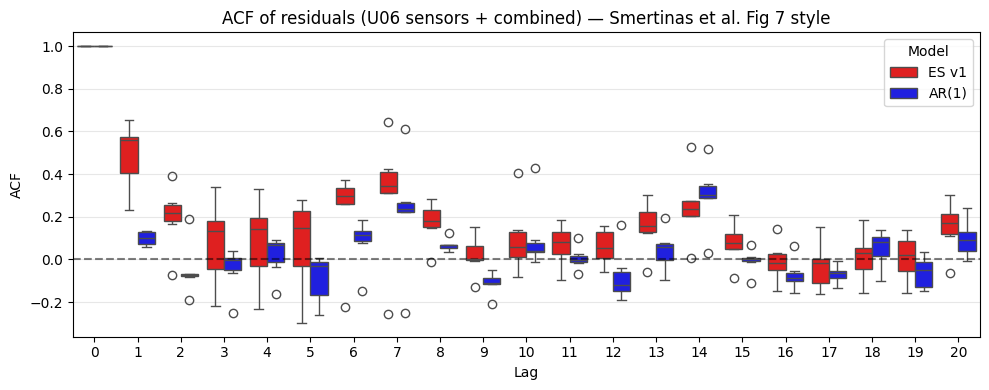

In [79]:
# --- Fig 7 style: ACF of residuals (Smertinas et al. Fig 7) ---
# Paper: box plot of ACF at lags 0..20 for ES, ARX-ES, ARMAX-ES. We use ES v1 vs AR(1), across sensors.

from sklearn.linear_model import LinearRegression

def get_residuals_acf(df, heat_cols, max_lag=21):
    """Build daily, fit v1 and AR1, return (res_v1, res_ar1) and ACF for lags 0..max_lag-1."""
    cols = [heat_cols] if isinstance(heat_cols, str) else list(heat_cols)
    phi = df[cols].sum(axis=1) if len(cols) > 1 else df[cols[0]]
    es = df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
    es["Phi_kWh"] = phi * 1e3
    es = es.dropna()
    es["date"] = es["datetime"].dt.date
    daily = (
        es.groupby("date", as_index=False)
        .agg(daily_heat_kWh=("Phi_kWh", "sum"), daily_T_out_c=("air_temp_c", "mean"),
             daily_wind_ms=("wind_speed_ms", "mean"), daily_sun_min=("sunshine_duration_min", "sum"))
    )
    daily = daily.dropna()
    daily = daily[daily["daily_heat_kWh"] > 0].sort_values("date").reset_index(drop=True)
    if len(daily) < 30:
        return None, None, None
    X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]]
    y = daily["daily_heat_kWh"]
    res_v1 = y - LinearRegression().fit(X, y).predict(X)
    daily["lag1"] = daily["daily_heat_kWh"].shift(1)
    d = daily.dropna(subset=["lag1"])
    Xar = d[["daily_T_out_c", "daily_wind_ms", "daily_sun_min", "lag1"]]
    yar = d["daily_heat_kWh"]
    res_ar1 = yar - LinearRegression().fit(Xar, yar).predict(Xar)
    def acf(series, max_lag):
        out = []
        for lag in range(max_lag):
            if lag == 0:
                out.append(1.0)
            else:
                out.append(series.autocorr(lag) if len(series) > lag else np.nan)
        return out
    return acf(res_v1, max_lag), acf(res_ar1, max_lag), max_lag

HEAT_METERS = [f"bhb{i:02d}" for i in range(1, 7)]
delta_cols = [f"{m}_measurement_delta_mwh" for m in HEAT_METERS]
rows_acf = []
for m in HEAT_METERS:
    a1, a2, ml = get_residuals_acf(building_2023_df, f"{m}_measurement_delta_mwh")
    if a1 is None:
        continue
    for lag in range(ml):
        if not np.isnan(a1[lag]):
            rows_acf.append({"sensor": m, "model": "ES v1", "lag": lag, "ACF": a1[lag]})
        if not np.isnan(a2[lag]):
            rows_acf.append({"sensor": m, "model": "AR(1)", "lag": lag, "ACF": a2[lag]})
a1, a2, ml = get_residuals_acf(building_2023_df, delta_cols)
if a1 is not None:
    for lag in range(ml):
        if not np.isnan(a1[lag]):
            rows_acf.append({"sensor": "all", "model": "ES v1", "lag": lag, "ACF": a1[lag]})
        if not np.isnan(a2[lag]):
            rows_acf.append({"sensor": "all", "model": "AR(1)", "lag": lag, "ACF": a2[lag]})
df_acf = pd.DataFrame(rows_acf)
if len(df_acf) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.boxplot(data=df_acf, x="lag", y="ACF", hue="model", ax=ax, palette={"ES v1": "red", "AR(1)": "blue"})
    ax.axhline(0, color="k", ls="--", alpha=0.5)
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")
    ax.set_title("ACF of residuals (U06 sensors + combined) — Smertinas et al. Fig 7 style")
    ax.legend(title="Model")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No ACF data (need enough daily rows per sensor).")

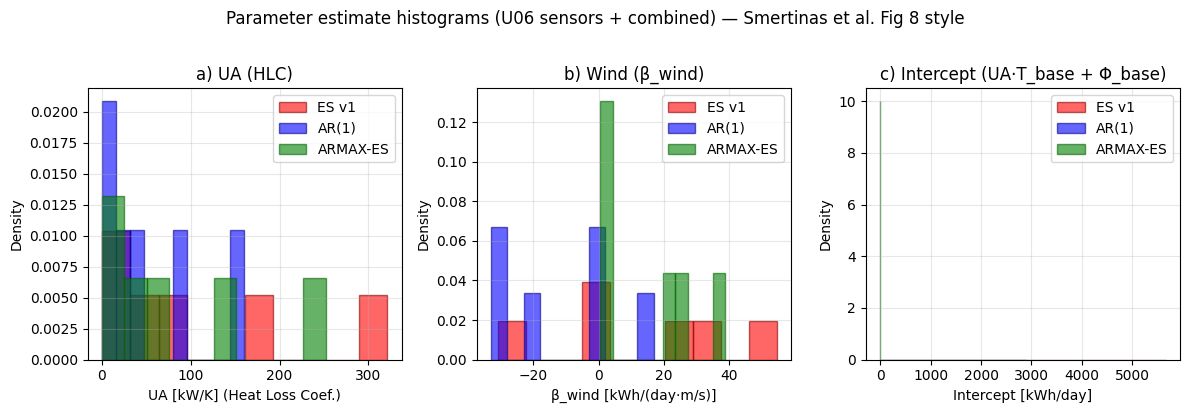

In [80]:
# --- Fig 8 style: Parameter histograms (Smertinas et al. Fig 8) ---
# Paper: UA₀, UAw, Tb, gA, Φbase, k for ES / ARX-ES / ARMAX-ES. We plot UA, β_wind, intercept for ES v1 vs AR(1) vs ARMAX.

sv1 = es_v1_summary.dropna(subset=["UA", "beta_wind", "intercept"])
sar1 = es_ar1_summary.dropna(subset=["UA", "beta_wind", "intercept"])
sarmax = es_armax_summary.dropna(subset=["UA", "beta_wind", "intercept"]) if "es_armax_summary" in dir() else pd.DataFrame()
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# UA (Heat Loss Coefficient)
ax = axes[0]
ax.hist(sv1["UA"], bins=10, alpha=0.6, color="red", label="ES v1", density=True, edgecolor="darkred")
ax.hist(sar1["UA"], bins=10, alpha=0.6, color="blue", label="AR(1)", density=True, edgecolor="darkblue")
if len(sarmax) > 0:
    ax.hist(sarmax["UA"], bins=10, alpha=0.6, color="green", label="ARMAX-ES", density=True, edgecolor="darkgreen")
ax.set_xlabel("UA [kW/K] (Heat Loss Coef.)")
ax.set_ylabel("Density")
ax.set_title("a) UA (HLC)")
ax.legend()
ax.grid(True, alpha=0.3)
# beta_wind
ax = axes[1]
ax.hist(sv1["beta_wind"], bins=10, alpha=0.6, color="red", label="ES v1", density=True, edgecolor="darkred")
ax.hist(sar1["beta_wind"], bins=10, alpha=0.6, color="blue", label="AR(1)", density=True, edgecolor="darkblue")
if len(sarmax) > 0:
    ax.hist(sarmax["beta_wind"], bins=10, alpha=0.6, color="green", label="ARMAX-ES", density=True, edgecolor="darkgreen")
ax.set_xlabel("β_wind [kWh/(day·m/s)]")
ax.set_ylabel("Density")
ax.set_title("b) Wind (β_wind)")
ax.legend()
ax.grid(True, alpha=0.3)
# intercept
ax = axes[2]
ax.hist(sv1["intercept"], bins=10, alpha=0.6, color="red", label="ES v1", density=True, edgecolor="darkred")
ax.hist(sar1["intercept"], bins=10, alpha=0.6, color="blue", label="AR(1)", density=True, edgecolor="darkblue")
if len(sarmax) > 0:
    ax.hist(sarmax["intercept"], bins=10, alpha=0.6, color="green", label="ARMAX-ES", density=True, edgecolor="darkgreen")
ax.set_xlabel("Intercept [kWh/day]")
ax.set_ylabel("Density")
ax.set_title("c) Intercept (UA·T_base + Φ_base)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.suptitle("Parameter estimate histograms (U06 sensors + combined) — Smertinas et al. Fig 8 style", y=1.02)
plt.tight_layout()
plt.show()

---
## ES + ARMAX (Smertinas et al. third model)

The paper’s **ARMAX-ES** model adds a **Moving Average (MA)** term to ARX-ES: it models the *errors* with MA(3), so

**Φ(t) = weather terms + ρ·Φ(t−1) + ε(t) + ν₁ε(t−1) + ν₂ε(t−2) + ν₃ε(t−3)**

with ε(t) the regression errors. This approximates grey-box dynamics and often improves one-step fit and residual ACF.

We implement it as **ARIMA(1,0,3)** with exogenous regressors (T_out, wind, sun) using `statsmodels`. The **Gaussian R²** (coefficient of determination) is R² = 1 − SS_res/SS_tot on the fitted values, same interpretation as for ES v1 and AR(1).

**Dependency:** `pip install statsmodels` (required for ARMAX-ES).

In [ ]:
def run_es_armax(df, heat_columns, label=None, order=(1, 0, 3)):
    """
    ES + ARMAX: ARIMA(1,0,3) with exogenous regressors (T_out, wind, sun).
    Same daily aggregation as ES v1 / AR(1). Returns dict with R2 (Gaussian R²), RMSE,
    UA, beta_wind, beta_sun, intercept (from exog), rho (AR coef), ma coefs.
    """
    import warnings
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tools.sm_exceptions import ConvergenceWarning

    cols = [heat_columns] if isinstance(heat_columns, str) else list(heat_columns)
    phi_mwh = df[cols].sum(axis=1) if len(cols) > 1 else df[cols[0]]
    es = df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
    es["Phi_kWh"] = phi_mwh * 1e3
    es = es.dropna()
    es["date"] = es["datetime"].dt.date
    daily = (
        es.groupby("date", as_index=False)
        .agg(
            daily_heat_kWh=("Phi_kWh", "sum"),
            daily_T_out_c=("air_temp_c", "mean"),
            daily_wind_ms=("wind_speed_ms", "mean"),
            daily_sun_min=("sunshine_duration_min", "sum"),
        )
    )
    daily = daily.dropna()
    daily = daily[daily["daily_heat_kWh"] > 0].sort_values("date").reset_index(drop=True)
    if len(daily) < 40:  # need enough for AR(1)+MA(3)
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}

    y = daily["daily_heat_kWh"].values
    X = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]].values

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", ConvergenceWarning)
            mod = ARIMA(y, exog=X, order=order)
            res = mod.fit()
    except Exception:
        return {"sensor": label, "n_days": len(daily), "R2": np.nan, "RMSE": np.nan}

    fitted = res.fittedvalues
    resid = y - fitted
    ss_res = np.sum(resid ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean(resid ** 2))

    # Exog coefs: statsmodels order is (const, x1, x2, x3, ar.L1, ma.L1, ma.L2, ma.L3)
    params = np.asarray(res.params)
    n_exog = res.model.k_exog  # 4 if trend='c' (const + 3 exog)
    intercept = float(params[0]) if n_exog >= 4 else 0.0
    ua = -float(params[1]) if len(params) > 1 else np.nan
    beta_wind = float(params[2]) if len(params) > 2 else np.nan
    beta_sun = -float(params[3]) if len(params) > 3 else np.nan
    rho = float(res.arparams[0]) if hasattr(res, "arparams") and len(res.arparams) > 0 else np.nan
    ma_coefs = list(res.maparams) if hasattr(res, "maparams") else []

    return {
        "sensor": label or str(cols),
        "UA": ua,
        "beta_wind": beta_wind,
        "beta_sun": beta_sun,
        "intercept": intercept,
        "rho": rho,
        "ma_coefs": ma_coefs,
        "R2": r2,
        "RMSE": rmse,
        "n_days": len(daily),
    }

---
## Reality vs predicted heat demand

Plot actual daily heat vs model predictions for ES v1, AR(1), and ARMAX-ES (e.g. for aggregate "all" or a single sensor). **Time series:** actual and predicted over time. **Scatter:** actual vs predicted (points on the diagonal = perfect fit).

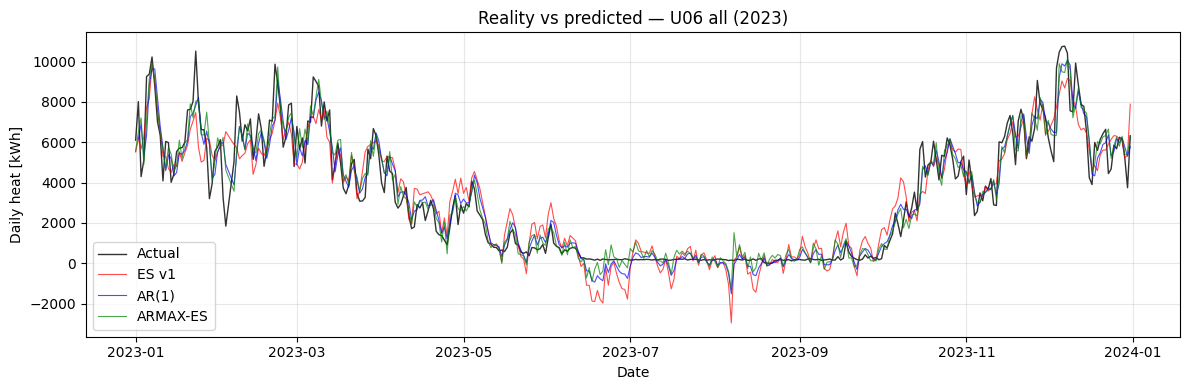

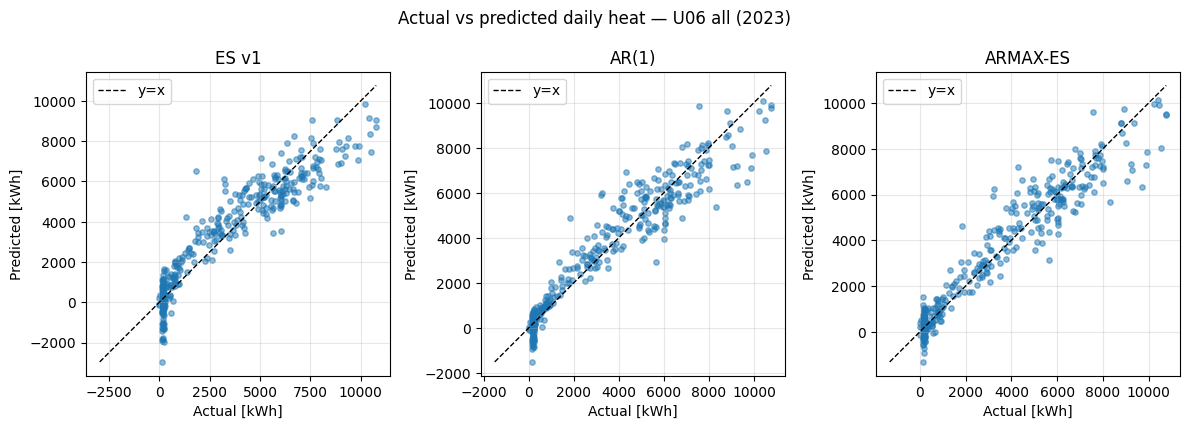

In [82]:
# Build daily data and fitted values for one target (e.g. "all" or "bhb01"), then plot reality vs predicted.
from sklearn.linear_model import LinearRegression

target = "all"  # or e.g. "bhb01"
heat_cols = delta_cols if target == "all" else [f"{target}_measurement_delta_mwh"]
phi_mwh = building_2023_df[heat_cols].sum(axis=1) if len(heat_cols) > 1 else building_2023_df[heat_cols[0]]
es = building_2023_df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"]].copy()
es["Phi_kWh"] = phi_mwh * 1e3
es = es.dropna()
es["date"] = es["datetime"].dt.date
daily = es.groupby("date", as_index=False).agg(
    daily_heat_kWh=("Phi_kWh", "sum"),
    daily_T_out_c=("air_temp_c", "mean"),
    daily_wind_ms=("wind_speed_ms", "mean"),
    daily_sun_min=("sunshine_duration_min", "sum"),
)
daily = daily.dropna()
daily = daily[daily["daily_heat_kWh"] > 0].sort_values("date").reset_index(drop=True)
daily["date_dt"] = pd.to_datetime(daily["date"])

# ES v1 predictions
X_v1 = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]]
y = daily["daily_heat_kWh"]
lm_v1 = LinearRegression().fit(X_v1, y)
daily["pred_v1"] = lm_v1.predict(X_v1)

# AR(1) predictions (drop first row for lag)
daily["lag1"] = daily["daily_heat_kWh"].shift(1)
d_ar1 = daily.dropna(subset=["lag1"])
X_ar1 = d_ar1[["daily_T_out_c", "daily_wind_ms", "daily_sun_min", "lag1"]]
lm_ar1 = LinearRegression().fit(X_ar1, d_ar1["daily_heat_kWh"])
daily["pred_ar1"] = np.nan
daily.loc[d_ar1.index, "pred_ar1"] = lm_ar1.predict(X_ar1)

# ARMAX-ES fitted values
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning
y_arr = daily["daily_heat_kWh"].values
X_exog = daily[["daily_T_out_c", "daily_wind_ms", "daily_sun_min"]].values
try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        mod = ARIMA(y_arr, exog=X_exog, order=(1, 0, 3))
        res_armax = mod.fit()
    daily["pred_armax"] = res_armax.fittedvalues
except Exception:
    daily["pred_armax"] = np.nan

# --- Plot 1: Time series (actual vs predicted) ---
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily["date_dt"], daily["daily_heat_kWh"], "k-", alpha=0.8, lw=1, label="Actual")
ax.plot(daily["date_dt"], daily["pred_v1"], "r-", alpha=0.7, lw=0.8, label="ES v1")
ax.plot(daily["date_dt"], daily["pred_ar1"], "b-", alpha=0.7, lw=0.8, label="AR(1)")
ax.plot(daily["date_dt"], daily["pred_armax"], "g-", alpha=0.7, lw=0.8, label="ARMAX-ES")
ax.set_xlabel("Date")
ax.set_ylabel("Daily heat [kWh]")
ax.set_title(f"Reality vs predicted — U06 {target} (2023)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Scatter actual vs predicted (one panel per model) ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, name in zip(axes, ["pred_v1", "pred_ar1", "pred_armax"], ["ES v1", "AR(1)", "ARMAX-ES"]):
    valid = daily[[col, "daily_heat_kWh"]].dropna()
    if len(valid) == 0:
        ax.set_title(f"{name} (no data)")
        continue
    ax.scatter(valid["daily_heat_kWh"], valid[col], alpha=0.5, s=15)
    lims = [min(valid["daily_heat_kWh"].min(), valid[col].min()), max(valid["daily_heat_kWh"].max(), valid[col].max())]
    ax.plot(lims, lims, "k--", lw=1, label="y=x")
    ax.set_xlabel("Actual [kWh]")
    ax.set_ylabel("Predicted [kWh]")
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")
fig.suptitle(f"Actual vs predicted daily heat — U06 {target} (2023)", y=1.02)
plt.tight_layout()
plt.show()

---
## R² summary and cross-building generalization (U06 vs U05)

Below we:
1. **Summarize R²** for U06 (ES v1, AR(1), ARMAX-ES).
2. **Run the same models on U05** (similar building: same year built/renovated, same facing, ~100 m apart).
3. **Compare** R² and key parameters between U06 and U05 to see how well the model form generalizes across similar buildings.

In [83]:
# --- R² summary (U06) and cross-building generalization (U06 vs U05) ---

# 1. R² summary for U06
print("=== U06 (2023) R² summary ===\n")
valid = compare.dropna(subset=["R2_v1", "R2_AR1"])
if "R2_ARMAX" in compare.columns:
    valid = valid.dropna(subset=["R2_ARMAX"])
print(valid[["sensor", "R2_v1", "R2_AR1", "R2_ARMAX", "RMSE_v1", "RMSE_AR1", "RMSE_ARMAX"]].to_string(index=False))
print("\nMedians (excluding NaN):")
for col in ["R2_v1", "R2_AR1", "R2_ARMAX"]:
    if col in compare.columns and compare[col].notna().any():
        print(f"  {col}: {compare[col].median():.3f}")

# 2. Load U05 (similar building: same year built/renovated, same facing, ~100 m apart)
df_u05 = building_data_loader.get_building_dataframe("U05")
u05_2023 = df_u05[df_u05["datetime"].dt.year == 2023].copy()

# U05 may have different BHB set; use only columns that exist
HEAT_METERS_U05 = [f"bhb{i:02d}" for i in range(1, 7)]
delta_cols_u05 = [f"{m}_measurement_delta_mwh" for m in HEAT_METERS_U05]
delta_cols_u05 = [c for c in delta_cols_u05 if c in u05_2023.columns]

# 3. Run same models on U05
rows_v1_u05, rows_ar1_u05, rows_armax_u05 = [], [], []
for m in HEAT_METERS_U05:
    col = f"{m}_measurement_delta_mwh"
    if col not in u05_2023.columns:
        continue
    rows_v1_u05.append(run_es_v1(u05_2023, col, label=m))
    rows_ar1_u05.append(run_es_ar1(u05_2023, col, label=m))
    rows_armax_u05.append(run_es_armax(u05_2023, col, label=m))
if delta_cols_u05:
    rows_v1_u05.append(run_es_v1(u05_2023, delta_cols_u05, label="all"))
    rows_ar1_u05.append(run_es_ar1(u05_2023, delta_cols_u05, label="all"))
    rows_armax_u05.append(run_es_armax(u05_2023, delta_cols_u05, label="all"))

es_v1_u05 = pd.DataFrame(rows_v1_u05)
es_ar1_u05 = pd.DataFrame(rows_ar1_u05)
es_armax_u05 = pd.DataFrame(rows_armax_u05)

compare_u05 = es_v1_u05[["sensor", "R2", "RMSE"]].copy()
compare_u05 = compare_u05.rename(columns={"R2": "R2_v1", "RMSE": "RMSE_v1"})
compare_u05["R2_AR1"] = es_ar1_u05["R2"].values
compare_u05["RMSE_AR1"] = es_ar1_u05["RMSE"].values
compare_u05["R2_ARMAX"] = es_armax_u05["R2"].values
compare_u05["RMSE_ARMAX"] = es_armax_u05["RMSE"].values
compare_u05["rho"] = es_ar1_u05["rho"].values

print("\n=== U05 (2023) R² summary ===\n")
print(compare_u05[["sensor", "R2_v1", "R2_AR1", "R2_ARMAX", "RMSE_v1", "RMSE_AR1", "RMSE_ARMAX"]].to_string(index=False))

# 4. Side-by-side: U06 vs U05 (match by sensor)
sensors_common = list(set(compare["sensor"].dropna()) & set(compare_u05["sensor"]))
sensors_common = [s for s in compare["sensor"] if s in sensors_common]  # preserve U06 order
cmp = pd.DataFrame({"sensor": sensors_common})
for col in ["R2_v1", "R2_AR1", "R2_ARMAX"]:
    cmp[f"U06_{col}"] = cmp["sensor"].map(compare.set_index("sensor")[col])
    cmp[f"U05_{col}"] = cmp["sensor"].map(compare_u05.set_index("sensor")[col])
    cmp[f"diff_{col}"] = cmp[f"U05_{col}"] - cmp[f"U06_{col}"]
print("\n=== U06 vs U05 R² comparison (same sensor / aggregate) ===\n")
print(cmp.to_string(index=False))

# 5. How well does the model generalize?
print("\n=== Generalization (U06 vs U05) ===\n")
for col in ["R2_v1", "R2_AR1", "R2_ARMAX"]:
    u06_med = compare[col].median()
    u05_med = compare_u05[col].median()
    print(f"  {col}: U06 median = {u06_med:.3f}, U05 median = {u05_med:.3f}, Δ = {u05_med - u06_med:+.3f}")
print("\nIf medians are similar and per-sensor R² track (U06 high → U05 high), the model form")
print("generalizes well across these two similar buildings. Large drops on U05 suggest building-")
print("specific behaviour or data quality differences.")

=== U06 (2023) R² summary ===

sensor    R2_v1   R2_AR1  R2_ARMAX     RMSE_v1   RMSE_AR1  RMSE_ARMAX
 bhb01 0.871536 0.917214  0.922039  630.576478 506.400102  491.229626
 bhb02 0.208549 0.240145  0.385779    6.430820   6.358576    5.665222
 bhb03 0.593780 0.792469  0.805634  261.826770 186.415220  181.110559
 bhb04 0.861914 0.912803  0.920466  291.793990 232.142518  221.450237
 bhb05 0.127405 0.242351  0.297373   22.378006  20.851875   20.080630
   all 0.876374 0.919091  0.924544 1047.536400 847.569310  818.395011

Medians (excluding NaN):
  R2_v1: 0.728
  R2_AR1: 0.853
  R2_ARMAX: 0.863


/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/mihkeluutar/Documents/TalTech/Thesis/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



=== U05 (2023) R² summary ===

sensor    R2_v1   R2_AR1  R2_ARMAX    RMSE_v1   RMSE_AR1  RMSE_ARMAX
 bhb01 0.805012 0.875256  0.880026 480.726536 384.846873  377.083705
 bhb02 0.685048 0.850094  0.860312 357.982150 247.273962  238.406582
 bhb03 0.533880 0.631896  0.678901 222.496946 197.946936  184.669313
 bhb04 0.144591 0.186861  0.183556   6.430504   6.277849    6.282335
 bhb05 0.297806 0.599281  0.672204  10.266738   7.771851    7.014645
 bhb06 0.802073 0.879840  0.869579   7.557170   5.893940    6.134519
   all 0.810038 0.879116  0.883661 924.817242 738.378983  723.744237

=== U06 vs U05 R² comparison (same sensor / aggregate) ===

sensor  U06_R2_v1  U05_R2_v1  diff_R2_v1  U06_R2_AR1  U05_R2_AR1  diff_R2_AR1  U06_R2_ARMAX  U05_R2_ARMAX  diff_R2_ARMAX
 bhb01   0.871536   0.805012   -0.066524    0.917214    0.875256    -0.041958      0.922039      0.880026      -0.042013
 bhb02   0.208549   0.685048    0.476498    0.240145    0.850094     0.609950      0.385779      0.860312       0

---
## 2024 hourly baselines for U06

We build **2024 hourly demand baselines** for U06 using:
- **ES-hourly (weather-only)**: linear model on 2023 hours, using `T_out`, wind, and sun.
- **Naive 24h-lag**: predict each hour by the demand 24 hours earlier.
- **AR(1)+weather (one-step, full-history)**: hourly AR(1) with weather regressors, trained on 2023 and evaluated using actual 2023–2024 history.

For each, we report **MAE / RMSE / MAPE on 2024** and plot a short 2024 window (actual vs predictions).

Hourly rows — 2023: 8729, 2024: 8755
After dropping top 0.5% 2024 outliers (Phi_kWh > 677.2), rows: 8711

=== 2024 hourly error metrics (U06, all meters summed) ===


,model,N,MAE_kWh,RMSE_kWh,MAPE_%
0,ES-hourly (weather),8711,85.786935,108.368930,3.052722e+06
1,Naive 24h lag,8711,26.313894,113.741490,7.763858e+05
2,AR(1)+weather (act),8711,47.558164,76.356359,1.725311e+06


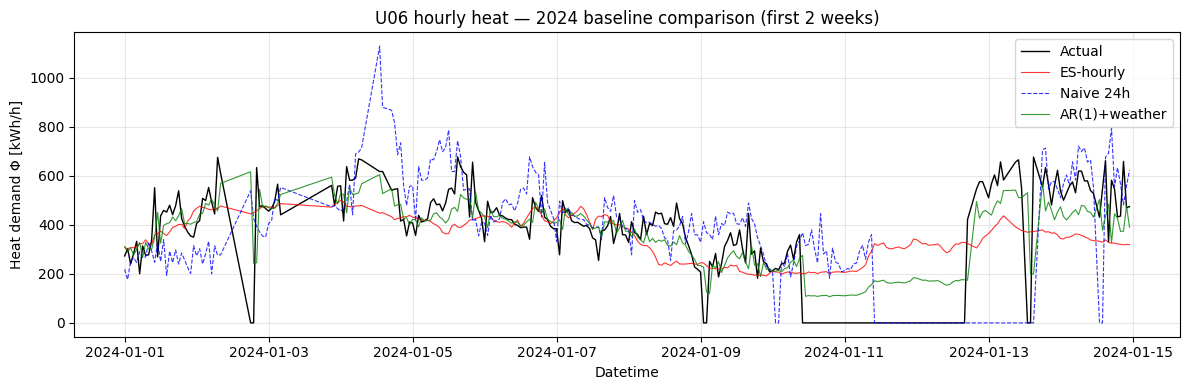

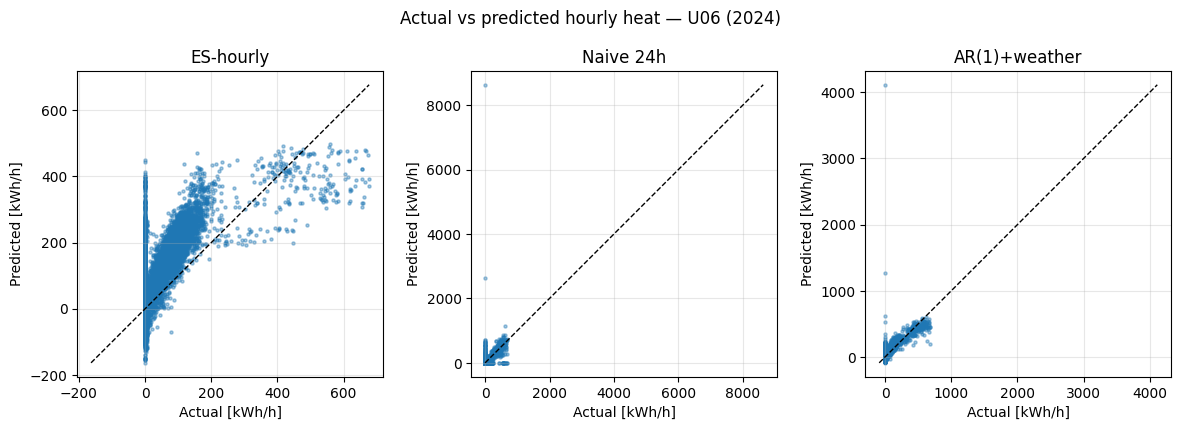

In [84]:
# --- 2024 hourly baselines: ES-hourly, naive 24h, AR(1)+weather ---

from sklearn.linear_model import LinearRegression

# Build hourly ES-style inputs for all available years using ALL heat meters
heat_cols_all = [c for c in building_df.columns if c.endswith("_measurement_delta_mwh")]

es_all_hours = building_df[["datetime", "air_temp_c", "wind_speed_ms", "sunshine_duration_min"] + heat_cols_all].copy()
es_all_hours["Phi_kWh"] = es_all_hours[heat_cols_all].sum(axis=1) * 1e3
es_all_hours = es_all_hours.rename(columns={
    "air_temp_c": "T_out_c",
    "wind_speed_ms": "wind_ms",
    "sunshine_duration_min": "sun_min",
})
es_all_hours = es_all_hours[["datetime", "T_out_c", "wind_ms", "sun_min", "Phi_kWh"]].dropna().sort_values("datetime").reset_index(drop=True)

es_all_hours["year"] = es_all_hours["datetime"].dt.year
es_2023 = es_all_hours[es_all_hours["year"] == 2023].copy()
es_2024 = es_all_hours[es_all_hours["year"] == 2024].copy()

print(f"Hourly rows — 2023: {len(es_2023)}, 2024: {len(es_2024)}")
if len(es_2024) == 0:
    raise RuntimeError("No 2024 hourly data available for U06 in building_df.")

# Drop top 0.5% largest 2024 hourly values to remove extreme outliers (e.g. 8000 kWh spikes)
q_hi = es_2024["Phi_kWh"].quantile(0.995)
es_2024 = es_2024[es_2024["Phi_kWh"] <= q_hi].copy()
print(f"After dropping top 0.5% 2024 outliers (Phi_kWh > {q_hi:.1f}), rows: {len(es_2024)}")

# 1) ES-hourly (weather-only) trained on 2023, applied to 2024
X_2023_weather = es_2023[["T_out_c", "wind_ms", "sun_min"]].values
y_2023 = es_2023["Phi_kWh"].values

lm_es_hourly = LinearRegression().fit(X_2023_weather, y_2023)

X_2024_weather = es_2024[["T_out_c", "wind_ms", "sun_min"]].values
es_2024 = es_2024.copy()
es_2024["pred_ES_weather"] = lm_es_hourly.predict(X_2024_weather)

# 2) Naive 24h-lag baseline: Φ_hat(t) = Φ(t-24h)
# Use the same combined hourly table so the lag is continuous across year boundary
es_all_hours["Phi_kWh_lag24"] = es_all_hours["Phi_kWh"].shift(24)
es_2024_naive = es_all_hours[es_all_hours["year"] == 2024].copy()
es_2024_naive = es_2024_naive.dropna(subset=["Phi_kWh_lag24"])
es_2024_naive["pred_naive_24h"] = es_2024_naive["Phi_kWh_lag24"]
# Apply same 0.5% high-end cut to naive baseline
es_2024_naive = es_2024_naive[es_2024_naive["Phi_kWh"] <= q_hi].copy()

# 3) AR(1)+weather hourly, using ACTUAL previous hour (full-history one-step baseline)
es_all_hours["Phi_kWh_lag1"] = es_all_hours["Phi_kWh"].shift(1)
es_2023_ar = es_all_hours[(es_all_hours["year"] == 2023) & es_all_hours["Phi_kWh_lag1"].notna()].copy()

X_2023_ar = es_2023_ar[["T_out_c", "wind_ms", "sun_min", "Phi_kWh_lag1"]].values
y_2023_ar = es_2023_ar["Phi_kWh"].values

lm_ar1_hourly = LinearRegression().fit(X_2023_ar, y_2023_ar)

es_2024_ar = es_all_hours[(es_all_hours["year"] == 2024) & es_all_hours["Phi_kWh_lag1"].notna()].copy()
X_2024_ar = es_2024_ar[["T_out_c", "wind_ms", "sun_min", "Phi_kWh_lag1"]].values
es_2024_ar["pred_AR1_actual"] = lm_ar1_hourly.predict(X_2024_ar)
# Apply same 0.5% high-end cut to AR(1)+weather baseline
es_2024_ar = es_2024_ar[es_2024_ar["Phi_kWh"] <= q_hi].copy()

# --- Error metrics on 2024 ---

rows_err_2024 = []

def summarize_errors(df, pred_col, label):
    y_true = df["Phi_kWh"].values
    y_pred = df[pred_col].values
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs(y_true - y_pred) / np.maximum(y_true, 1e-3)) * 100.0
    rows_err_2024.append({
        "model": label,
        "N": len(df),
        "MAE_kWh": mae,
        "RMSE_kWh": rmse,
        "MAPE_%": mape,
    })

summarize_errors(es_2024, "pred_ES_weather", "ES-hourly (weather)")
summarize_errors(es_2024_naive, "pred_naive_24h", "Naive 24h lag")
summarize_errors(es_2024_ar, "pred_AR1_actual", "AR(1)+weather (act)")

err_2024_df = pd.DataFrame(rows_err_2024)
print("\n=== 2024 hourly error metrics (U06, all meters summed) ===")
display(err_2024_df)

# --- Plot: short 2024 window (e.g. first 2 weeks) ---

# Join predictions on datetime to a common frame for plotting
plot_df = es_2024[["datetime", "Phi_kWh", "pred_ES_weather"]].merge(
    es_2024_naive[["datetime", "pred_naive_24h"]], on="datetime", how="left"
).merge(
    es_2024_ar[["datetime", "pred_AR1_actual"]], on="datetime", how="left"
)

plot_start = pd.Timestamp("2024-01-01")
plot_end = plot_start + pd.Timedelta(days=14)
mask = (plot_df["datetime"] >= plot_start) & (plot_df["datetime"] < plot_end)
plot_slice = plot_df[mask].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(plot_slice["datetime"], plot_slice["Phi_kWh"], "k-", lw=1.0, label="Actual")
ax.plot(plot_slice["datetime"], plot_slice["pred_ES_weather"], "r-", lw=0.8, alpha=0.8, label="ES-hourly")
ax.plot(plot_slice["datetime"], plot_slice["pred_naive_24h"], "b--", lw=0.8, alpha=0.8, label="Naive 24h")
ax.plot(plot_slice["datetime"], plot_slice["pred_AR1_actual"], "g-", lw=0.8, alpha=0.8, label="AR(1)+weather")
ax.set_xlabel("Datetime")
ax.set_ylabel("Heat demand Φ [kWh/h]")
ax.set_title("U06 hourly heat — 2024 baseline comparison (first 2 weeks)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Scatter: actual vs predicted (2024) for each baseline ---

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
models = [
    (es_2024.dropna(subset=["pred_ES_weather"]), "pred_ES_weather", "ES-hourly"),
    (es_2024_naive.dropna(subset=["pred_naive_24h"]), "pred_naive_24h", "Naive 24h"),
    (es_2024_ar.dropna(subset=["pred_AR1_actual"]), "pred_AR1_actual", "AR(1)+weather"),
]

for ax, (df_m, col, name) in zip(axes, models):
    if len(df_m) == 0:
        ax.set_title(f"{name} (no data)")
        ax.axis("off")
        continue
    y_true = df_m["Phi_kWh"]
    y_pred = df_m[col]
    ax.scatter(y_true, y_pred, s=5, alpha=0.4)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Actual [kWh/h]")
    ax.set_ylabel("Predicted [kWh/h]")
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

plt.suptitle("Actual vs predicted hourly heat — U06 (2024)", y=1.02)
plt.tight_layout()
plt.show()